In [1]:
# Import the packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import category_encoders as ce
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import joblib
from pathlib import Path

pd.set_option("display.max_colwidth", None)

# Load the feature engineered Data for France 2024 (cleaned)

In [2]:
df_2024 = pd.read_csv("../data/processed/EU/2024_FR_cleaned.csv")
display(df_2024.head())

,Vehicle,m (kg),Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),Erwltp (g/km),Fuel consumption,Electric range (km),r,IT_28,IT_29,IT_32,IT_33,IT_37,IT_none
0,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS72VR21BAI0 - 1T - E1*2001/116*0211*63,1675.0,140.0,diesel,M,1968.0,110.0,0.0,1.00,5.3,0.0,3,0,1,0,0,0,0
1,VOLKSWAGEN - TOURAN - DTRCAF - FM6FM6C90044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1632.0,134.0,diesel,M,1968.0,90.0,0.0,1.00,5.1,0.0,1,0,1,0,0,0,0
2,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAI0 - 1T - E1*2001/116*0211*65,1631.0,137.0,diesel,M,1968.0,110.0,0.0,1.00,5.2,0.0,1,0,1,0,0,0,0
3,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAIM - 1T - E1*2001/116*0211*65,1631.0,137.0,diesel,M,1968.0,110.0,0.0,1.68,5.2,0.0,1,1,1,0,0,0,0
4,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1675.0,140.0,diesel,M,1968.0,110.0,0.0,1.00,5.3,0.0,1,0,1,0,0,0,0


In [3]:
df_2024.info()

<class 'pandas.DataFrame'>
RangeIndex: 119380 entries, 0 to 119379
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Vehicle              119380 non-null  str    
 1   m (kg)               119380 non-null  float64
 2   Ewltp (g/km)         119380 non-null  float64
 3   Ft                   119380 non-null  str    
 4   Fm                   119380 non-null  str    
 5   ec (cm3)             119380 non-null  float64
 6   ep (KW)              119380 non-null  float64
 7   z (Wh/km)            119380 non-null  float64
 8   Erwltp (g/km)        119380 non-null  float64
 9   Fuel consumption     119380 non-null  float64
 10  Electric range (km)  119380 non-null  float64
 11  r                    119380 non-null  int64  
 12  IT_28                119380 non-null  int64  
 13  IT_29                119380 non-null  int64  
 14  IT_32                119380 non-null  int64  
 15  IT_33                119380 

In [4]:
# Clean column headers (removes accidental spaces)
df_2024.columns = df_2024.columns.str.strip()

# Check dataset dimensions and view first few rows
print(f"Dataset shape: {df_2024.shape[0]} rows, {df_2024.shape[1]} columns")
df_2024.head()

Dataset shape: 119380 rows, 18 columns


,Vehicle,m (kg),Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),Erwltp (g/km),Fuel consumption,Electric range (km),r,IT_28,IT_29,IT_32,IT_33,IT_37,IT_none
0,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS72VR21BAI0 - 1T - E1*2001/116*0211*63,1675.0,140.0,diesel,M,1968.0,110.0,0.0,1.00,5.3,0.0,3,0,1,0,0,0,0
1,VOLKSWAGEN - TOURAN - DTRCAF - FM6FM6C90044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1632.0,134.0,diesel,M,1968.0,90.0,0.0,1.00,5.1,0.0,1,0,1,0,0,0,0
2,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAI0 - 1T - E1*2001/116*0211*65,1631.0,137.0,diesel,M,1968.0,110.0,0.0,1.00,5.2,0.0,1,0,1,0,0,0,0
3,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAIM - 1T - E1*2001/116*0211*65,1631.0,137.0,diesel,M,1968.0,110.0,0.0,1.68,5.2,0.0,1,1,1,0,0,0,0
4,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1675.0,140.0,diesel,M,1968.0,110.0,0.0,1.00,5.3,0.0,1,0,1,0,0,0,0


## Let's drop the **r** column:

In [5]:
# Drop non-predictive identifiers like 'ID' if present
if 'r' in df_2024.columns:
    df_2024 = df_2024.drop(columns=['r'])

df_2024.head()


,Vehicle,m (kg),Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),Erwltp (g/km),Fuel consumption,Electric range (km),IT_28,IT_29,IT_32,IT_33,IT_37,IT_none
0,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS72VR21BAI0 - 1T - E1*2001/116*0211*63,1675.0,140.0,diesel,M,1968.0,110.0,0.0,1.00,5.3,0.0,0,1,0,0,0,0
1,VOLKSWAGEN - TOURAN - DTRCAF - FM6FM6C90044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1632.0,134.0,diesel,M,1968.0,90.0,0.0,1.00,5.1,0.0,0,1,0,0,0,0
2,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAI0 - 1T - E1*2001/116*0211*65,1631.0,137.0,diesel,M,1968.0,110.0,0.0,1.00,5.2,0.0,0,1,0,0,0,0
3,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAIM - 1T - E1*2001/116*0211*65,1631.0,137.0,diesel,M,1968.0,110.0,0.0,1.68,5.2,0.0,1,1,0,0,0,0
4,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1675.0,140.0,diesel,M,1968.0,110.0,0.0,1.00,5.3,0.0,0,1,0,0,0,0


# Let's see the distributions of our categorical columns:

### Let's see the distribution of **"Vehicle"** column:

In [6]:
print("Unique categories:", df_2024['Vehicle'].nunique())
print("Missing values:", df_2024['Vehicle'].isnull().sum())
print("\nTop 10 most frequent vehicles:")
print(df_2024['Vehicle'].value_counts().head(10))

Unique categories: 15853
Missing values: 0

Top 10 most frequent vehicles:
Vehicle
LAND ROVER - RANGE ROVER SPORT - HYEDC0 - 5CAA000 - L1 - E9*2018/858*11229*02    371
LAND ROVER - RANGE ROVER SPORT - HYEEC0 - 5CAA000 - L1 - E9*2018/858*11229*05    362
BMW - X1 XDRIVE25E - 21EF - EAW50000 - U1X - E1*2018/858*00153*06                359
BMW - X1 XDRIVE25E - 21EF - EAW50000 - U1X - E1*2018/858*00153*05                306
PORSCHE - CAYENNE E-HYBRID - CL22 - 1510000 - 9YA - E13*2007/46*0900*15          268
BMW - X1 XDRIVE25E - 21EF - EAW50000 - U1X - E1*2018/858*00153*04                263
BMW - X1 SDRIVE20I - 31EE - FAV500L0 - U1X - E1*2018/858*00153*06                248
BMW - X5 XDRIVE50E - 41EU - EAA5090A - G5X - E1*2007/46*1918*18                  243
VOLVO - XC60 - UZH4 - UZH4VD - U - E4*2007/46*1220*22                            229
BMW - X1 SDRIVE20I - 31EE - IAW500L0 - U1X - E1*2018/858*00153*04                216
Name: count, dtype: int64


### The Vehicle variable in this dataset is a concatenated text string combining multiple fields (Make, Model, Variant, Version, Type Approval Number) separated by dashes.

### The most registered vehicle in this set is a **LAND ROVER - RANGE ROVER SPORT** variant appearing 371 times.

In [7]:
# Extract the brand name (first part of the Vehicle string)
df_2024['Make'] = df_2024['Vehicle'].str.split(' - ').str[0].str.strip()

# Calculate registration counts and percentages
brand_counts = df_2024['Make'].value_counts()
brand_percentages = df_2024['Make'].value_counts(normalize=True) * 100

# Combine into a clean table format
major_brands = pd.DataFrame({
    'Total Registrations': brand_counts,
    'Market Share (%)': brand_percentages.round(2)
})

# Display the Top 30 manufacturers
print(major_brands.head(30))

               Total Registrations  Market Share (%)
Make                                                
BMW                          19376             16.23
MERCEDES-BENZ                16488             13.81
AUDI                         14461             12.11
VOLKSWAGEN                   11247              9.42
RENAULT                       8192              6.86
SKODA                         7876              6.60
PEUGEOT                       7333              6.14
LAND ROVER                    4058              3.40
PORSCHE                       3559              2.98
OPEL                          3037              2.54
CITROEN                       2489              2.08
VOLVO                         2452              2.05
CUPRA                         2433              2.04
SEAT                          2209              1.85
DACIA                         2164              1.81
DS                            2160              1.81
FORD                          1997            

## Display the Top 30 major brands along with their exact market share percentages

In [8]:
# Check how much total market share the Top 30 brands cover
top_30_coverage = brand_percentages.head(30).sum()
print(f"The top 30 brands cover {top_30_coverage:.2f}% of all registrations.")

The top 30 brands cover 99.61% of all registrations.


## That 99.61% coverage confirms that keeping the top 30 brands and grouping the rest into 'OTHER' is ideal for the dataset.

* Massive Volume Captured: The top 30 brands account for virtually the entire dataset across **119,380** registrations.

* Minimal Information Loss: The remaining **0.39%** consists of dozens of tiny or rare manufacturers that would only introduce noise if kept separate.

* Optimal Feature Size: Setting the **cutoff at 30 keeps** the feature space clean while preserving almost all real-world market signals.

In [9]:
#  Parse Vehicle into Make and Model
vehicle_split = df_2024['Vehicle'].str.split(' - ', expand=True)
df_2024['Make'] = vehicle_split[0].str.strip()
df_2024['Model'] = vehicle_split[1].str.strip()

#  Group brands outside top 30 into 'OTHER'
top_makes = df_2024['Make'].value_counts().nlargest(30).index
df_2024['Make_Grouped'] = df_2024['Make'].where(df_2024['Make'].isin(top_makes), 'OTHER')

#  Target Encode 'Make' (Average CO2 per brand)
make_map = df_2024.groupby('Make_Grouped')['Ewltp (g/km)'].mean().to_dict()
df_2024['Make_Encoded'] = df_2024['Make_Grouped'].map(make_map)

#  Frequency Encode 'Model' (Registration counts per model)
model_counts = df_2024['Model'].value_counts().to_dict()
df_2024['Model_Frequency'] = df_2024['Model'].map(model_counts)

# Drop raw text columns
df_2024 = df_2024.drop(columns=['Make', 'Model', 'Make_Grouped'])

In [10]:
# Show the distribution and summary stats of Make_Encoded
print("Distinct Encoded Values Count:", df_2024['Make_Encoded'].nunique())
print("\nTop 10 Most Common Encoded Values:")
print(df_2024['Make_Encoded'].value_counts().head(10))

Distinct Encoded Values Count: 31

Top 10 Most Common Encoded Values:
Make_Encoded
99.837118     19376
79.251031     16488
109.635986    14461
122.325509    11247
124.719360     8192
124.731463     7876
100.643257     7333
48.271809      4058
54.268896      3559
115.580178     3037
Name: count, dtype: int64


In [11]:
df_2024.info()

<class 'pandas.DataFrame'>
RangeIndex: 119380 entries, 0 to 119379
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Vehicle              119380 non-null  str    
 1   m (kg)               119380 non-null  float64
 2   Ewltp (g/km)         119380 non-null  float64
 3   Ft                   119380 non-null  str    
 4   Fm                   119380 non-null  str    
 5   ec (cm3)             119380 non-null  float64
 6   ep (KW)              119380 non-null  float64
 7   z (Wh/km)            119380 non-null  float64
 8   Erwltp (g/km)        119380 non-null  float64
 9   Fuel consumption     119380 non-null  float64
 10  Electric range (km)  119380 non-null  float64
 11  IT_28                119380 non-null  int64  
 12  IT_29                119380 non-null  int64  
 13  IT_32                119380 non-null  int64  
 14  IT_33                119380 non-null  int64  
 15  IT_37                119380 

#### Let's see the distribution of **"Ft"** column:

Let's remember the Ft and Fm modes: 

**Ft** modes:
- petrol
- petrol/electric
- diesel
- diesel/electric
- e85
- lpg  

**Fm modes:**
- **"M":** Mono-Fuel / Single-Fuel
- **"H":** Hybrid / Standard Hybrid
- **"E":** Battery Electric Vehicle - BEV / Fully Electric
- **"B":** Bi-Fuel / Dual-Fuel
- **"P":** PHEV (Plug-in Hybrid Electric Vehicle)
- **"F":** Flex-Fuel / Flexible Fuel


In [12]:
print("Unique Fuel Types (Ft):", df_2024['Ft'].nunique())
print("Unique Fuel Modes (Fm):", df_2024['Fm'].nunique())
print("\n*************\n")

print("Ft categories:", df_2024['Ft'].unique())
print("Fm categories:", df_2024['Fm'].unique())
print("\n*************\n")

print("Ft: Fuel type distribution")
print(df_2024["Ft"].value_counts()/len(df_2024)*100)
print("\n*************\n")

print("Fm: Fuel mode distribution")
print(df_2024["Fm"].value_counts()/len(df_2024)*100)



Unique Fuel Types (Ft): 6
Unique Fuel Modes (Fm): 5

*************

Ft categories: <ArrowStringArray>
['diesel', 'petrol', 'petrol/electric', 'diesel/electric', 'e85', 'lpg']
Length: 6, dtype: str
Fm categories: <ArrowStringArray>
['M', 'P', 'H', 'B', 'F']
Length: 5, dtype: str

*************

Ft: Fuel type distribution
Ft
petrol             43.726755
petrol/electric    29.221813
diesel             23.289496
diesel/electric     2.498744
e85                 0.676830
lpg                 0.586363
Name: count, dtype: float64

*************

Fm: Fuel mode distribution
Fm
M    41.805998
P    31.720556
H    25.866979
B     0.586363
F     0.020104
Name: count, dtype: float64


### Let's define a cutoff at diesel, and drop diesel/electric, e85, and lpg data since they are very low.

In [13]:
allowed_fuel_types = ["petrol", "petrol/electric", "diesel"]
df_2024 = df_2024[df_2024["Ft"].isin(allowed_fuel_types)].copy()

print(" New Ft distribution:\n", df_2024["Ft"].value_counts(normalize=True)*100)
print("\n*************\n")
print("New Fm (Fuel mode) distribution")
print(df_2024["Fm"].value_counts()/len(df_2024)*100)

 New Ft distribution:
 Ft
petrol             45.436030
petrol/electric    30.364091
diesel             24.199880
Name: proportion, dtype: float64

*************

New Fm (Fuel mode) distribution
Fm
M    43.440190
P    30.364091
H    26.195719
Name: count, dtype: float64


So our data contains only the following modes for **Fuel Type (Ft):**
- petrol
- petrol/electric
- diesel

And only the following modes for **Fuel Mode (Fm):**
- **M:** Mono-Fuel / Single-Fuel
- **P:** PHEV (Plug-in Hybrid Electric Vehicle)
- **H:** Hybrid / Standard Hybrid

In [14]:
df_2024.info()

<class 'pandas.DataFrame'>
Index: 114889 entries, 0 to 119379
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Vehicle              114889 non-null  str    
 1   m (kg)               114889 non-null  float64
 2   Ewltp (g/km)         114889 non-null  float64
 3   Ft                   114889 non-null  str    
 4   Fm                   114889 non-null  str    
 5   ec (cm3)             114889 non-null  float64
 6   ep (KW)              114889 non-null  float64
 7   z (Wh/km)            114889 non-null  float64
 8   Erwltp (g/km)        114889 non-null  float64
 9   Fuel consumption     114889 non-null  float64
 10  Electric range (km)  114889 non-null  float64
 11  IT_28                114889 non-null  int64  
 12  IT_29                114889 non-null  int64  
 13  IT_32                114889 non-null  int64  
 14  IT_33                114889 non-null  int64  
 15  IT_37                114889 non-n

In [15]:
df_2024.head()

,Vehicle,m (kg),Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),Erwltp (g/km),Fuel consumption,Electric range (km),IT_28,IT_29,IT_32,IT_33,IT_37,IT_none,Make_Encoded,Model_Frequency
0,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS72VR21BAI0 - 1T - E1*2001/116*0211*63,1675.0,140.0,diesel,M,1968.0,110.0,0.0,1.00,5.3,0.0,0,1,0,0,0,0,122.325509,481
1,VOLKSWAGEN - TOURAN - DTRCAF - FM6FM6C90044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1632.0,134.0,diesel,M,1968.0,90.0,0.0,1.00,5.1,0.0,0,1,0,0,0,0,122.325509,481
2,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAI0 - 1T - E1*2001/116*0211*65,1631.0,137.0,diesel,M,1968.0,110.0,0.0,1.00,5.2,0.0,0,1,0,0,0,0,122.325509,481
3,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAIM - 1T - E1*2001/116*0211*65,1631.0,137.0,diesel,M,1968.0,110.0,0.0,1.68,5.2,0.0,1,1,0,0,0,0,122.325509,481
4,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1675.0,140.0,diesel,M,1968.0,110.0,0.0,1.00,5.3,0.0,0,1,0,0,0,0,122.325509,481


# Let's see the distributions of the numerical columns:

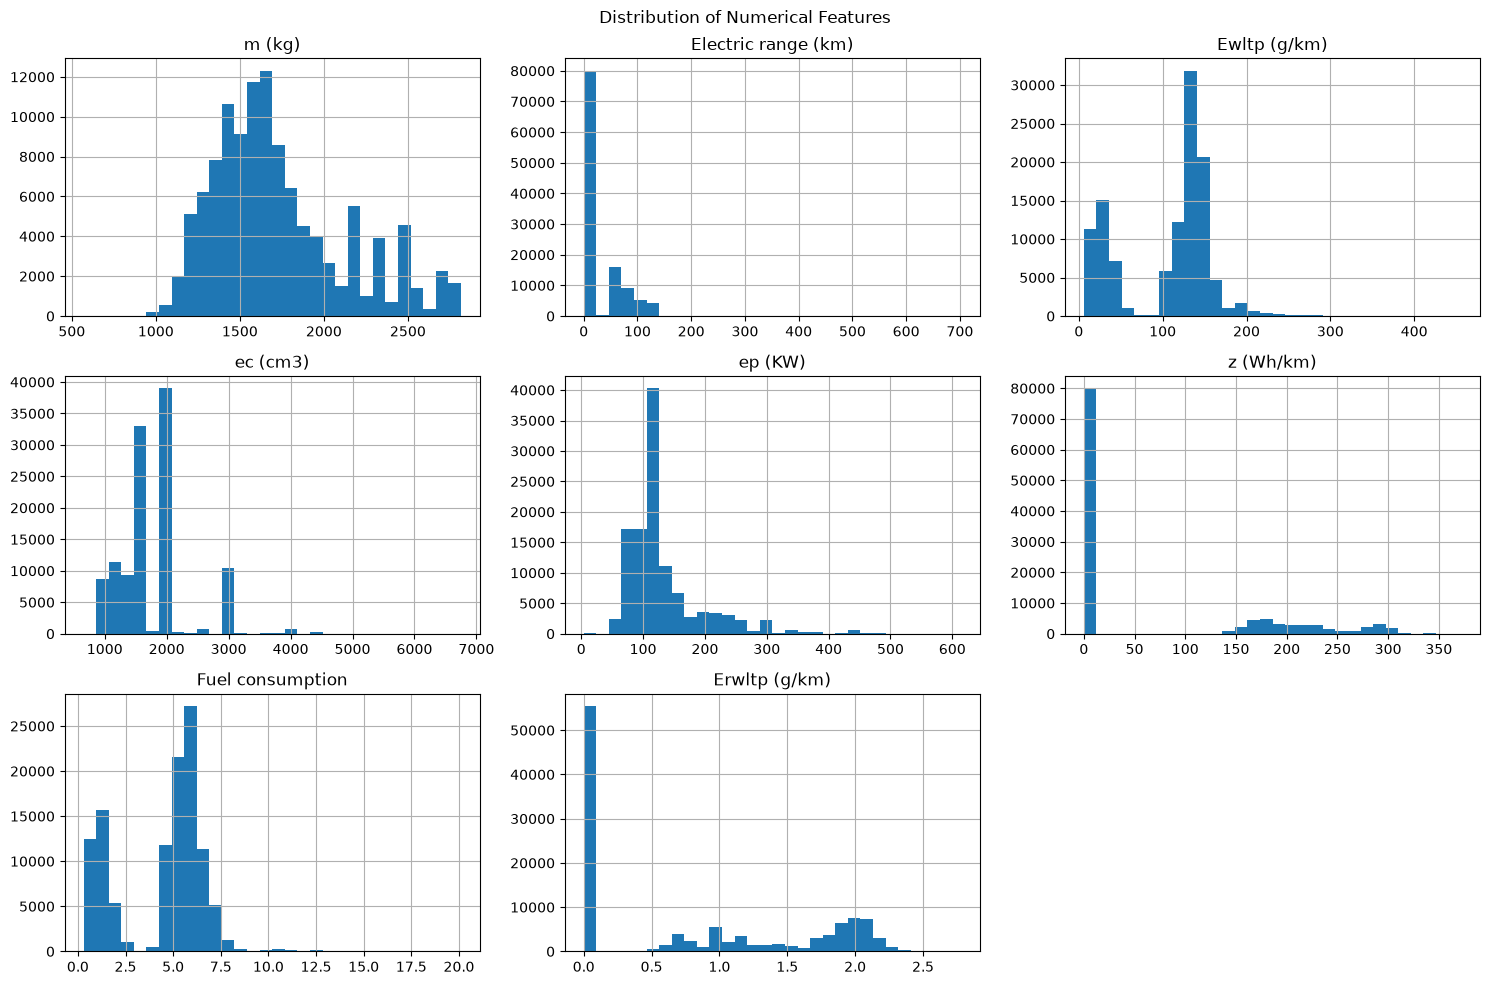

--- Feature Skewness ---
m (kg)                 0.847951
Electric range (km)    1.413554
Ewltp (g/km)          -0.344703
ec (cm3)               1.450836
ep (KW)                2.238082
z (Wh/km)              1.077609
Fuel consumption      -0.309755
Erwltp (g/km)          0.406650
dtype: float64


In [16]:
def dist_graphs():
    num_cols = [
        "m (kg)", "Electric range (km)", "Ewltp (g/km)", "ec (cm3)", "ep (KW)", "z (Wh/km)", "Fuel consumption", "Erwltp (g/km)"]
    
    # Keep only columns that actually exist in your dataset to avoid errors
    existing_num_cols = [col for col in num_cols if col in df_2024.columns]

    # Visual inspection of distributions
    df_2024[existing_num_cols].hist(bins=30, figsize=(15, 10))
    plt.suptitle("Distribution of Numerical Features")
    plt.tight_layout()
    plt.show()

    # Print Skewness to verify outlier presence
    print("--- Feature Skewness ---")
    print(df_2024[existing_num_cols].skew())
    
dist_graphs()


## Skewness measures the symmetry of a column's data distribution.

## Highly Right-Skewed (Skewness > 1.0):

* **ep (KW) (2.24)**: Strongly right-skewed with long tails to the right. Most vehicles have low-to-moderate engine power and equipment mass, with a few extreme high-performance or heavy outliers.

* **ec (cm3) (1.45)**, **Electric range (km) (1.41)**, and **z (Wh/km) (1.08)**: Moderately high right-skewness.

## Moderately Right-Skewed (0.5 to 1.0):

* **m (kg) (0.85)**: Fairly right-skewed mass data.

## Symmetric / Approximately Normal (-0.5 to 0.5):

* **Ewltp (g/km) (-0.34), Erwltp (g/km) (0.41), Fuel consumption (-0.31)**: Slightly negative or positive, but generally well-behaved and close to symmetric.


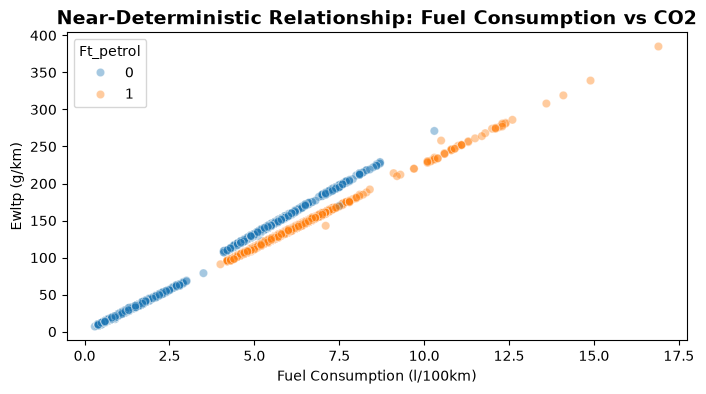

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

df_2024["Ft_petrol"] = ( # to be dropped later
    df_2024["Ft"] == "petrol"
).astype(int)

plt.figure(figsize=(8, 4))
# Filter out 0-consumption rows (like pure EVs) for cleaner visualization
combustion_df = df_2024[df_2024['Fuel consumption'] > 0]

sns.scatterplot(
    data=combustion_df.sample(5000, random_state=42), 
    x='Fuel consumption', 
    y='Ewltp (g/km)', 
    hue='Ft_petrol', 
    alpha=0.4
)
plt.title('Near-Deterministic Relationship: Fuel Consumption vs CO2', fontsize=14, fontweight='bold')
plt.xlabel('Fuel Consumption (l/100km)')
plt.ylabel('Ewltp (g/km)')
plt.show()

## The scatter plot demonstrates a near-perfect deterministic relationship between Fuel Consumption and Ewltp (g/km), separated neatly by fuel-type constants. Including Fuel Consumption introduces catastrophic target leakage, trivialising model training ($R^2 \approx 1.0$) and blinding the algorithm to physical vehicle engineering parameters like mass and power.

## The goal is to build a predictive machine learning model that estimates emissions based on physical vehicle design specs (like weight, engine displacement, and power output)
## The decision to drop:
* Prevents Target Leakage: As the scatter plot clearly demonstrated, Fuel consumption determines $\text{CO}_2$ mathematically. Keeping it means the model isn't predicting emissions—it's just solving a basic stoichiometry formula.
* It Keeps the Model Useful for Real-World Inference: Engineers and planners use ML models to answer questions like "If we build a car with 150 kW power weighing 1,800 kg, what will its $\text{CO}_2$ emissions be?" At the design stage, official laboratory fuel consumption numbers don't exist yet.
* It Forces Learning from Physical Attributes: Once dropped, the model will be forced to learn the actual physical relationships between Equipment_Mass, ec (cm3), ep (KW), and Make_Encoded to predict Ewltp (g/km).

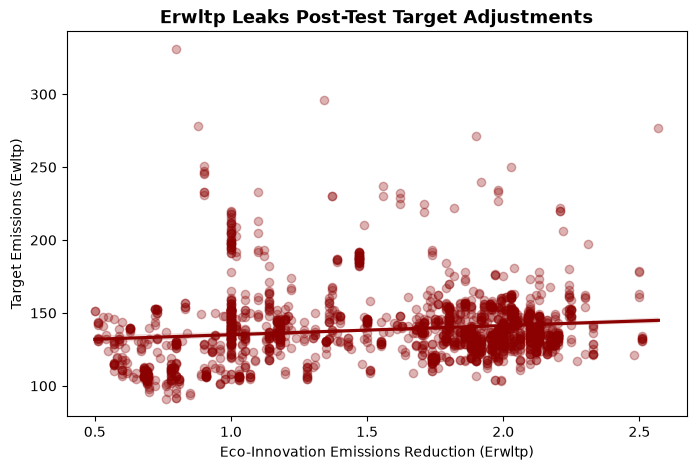

In [18]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_2024[df_2024['Erwltp (g/km)'] > 0].sample(2000, random_state=42),
    x='Erwltp (g/km)', 
    y='Ewltp (g/km)',
    color='darkred',
    scatter_kws={'alpha': 0.3}
)
plt.title('Erwltp Leaks Post-Test Target Adjustments', fontsize=13, fontweight='bold')
plt.xlabel('Eco-Innovation Emissions Reduction (Erwltp)')
plt.ylabel('Target Emissions (Ewltp)')
plt.show()

## Disconnect From Raw Physics
* Cluster Stacking: The plot shows clear vertical stacks at discrete x-axis values like $1.0$, $1.5$, and $2.0\text{ g/km}$, which fits the explanation of official regulatory tiers.
* Target Emissions Range: The explanation states that target emissions span from $110$ to $190+\text{ g/km}$, but the y-axis (Target Emissions Ewltp) clearly ranges from below $100\text{ g/km}$ up to $330+\text{ g/km}$. For instance, at the $1.0\text{ g/km}$ mark on the x-axis, the points span from around $105\text{ g/km}$ up to over $220\text{ g/km}$, and there are outliers reaching $330\text{ g/km}$.
* No Direct Correlation: Across any fixed reduction value (for example, at $1.50\text{ g/km}$), target emissions span from $110\text{ g/km}$ to $190+\text{ g/km}$. The flat, weak trend line shows that Erwltp provides almost no signal regarding baseline physical vehicle attributes (like weight, displacement, or engine power).

## Target Contamination & Regulatory Leakage
* Post-Test Offsets: Under EU regulatory frameworks, Erwltp represents an administrative credit subtracted from a vehicle's certified type-approval baseline.
* Model Corruption: Because Erwltp is calculated after standardised WLTP laboratory testing, including it allows the model to access regulatory adjustment credits rather than learning physical emissions dynamics from physical parameters (Equipment_Mass, ec, ep).

# We will drop **Fuel consumption** & **Erwltp (g/km)** columns since they force the model to rely purely on fundamental design and engineering specifications

## Let's analyse the outliers for our numerical columns:

In [19]:
def outlier_summary():
    num_cols = [
        "m (kg)", 
        "Electric range (km)", 
        "z (Wh/km)", 
        "Ewltp (g/km)", 
        "ec (cm3)", 
        "ep (KW)",
    ]
    
    outlier_rows = []
    
    for col in num_cols:
        series = df_2024[col]
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
    
        outlier_mask = (series < lower_bound) | (series > upper_bound)
    
        outlier_rows.append({
            "column": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_mask.sum(),
            "outlier_pct": round(outlier_mask.mean() * 100, 2),
            "min_outlier": series[outlier_mask].min(),
            "max_outlier": series[outlier_mask].max()
        })
     
    outlier_summary = (
        pd.DataFrame(outlier_rows)
        .set_index("column")
        .round(2)
    )
    
    display(outlier_summary)

outlier_summary()


,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct,min_outlier,max_outlier
column,,,,,,,,,
m (kg),1441.0,1930.0,489.0,707.5,2663.5,3933,3.42,570.0,2815.0
Electric range (km),0.0,57.0,57.0,-85.5,142.5,19,0.02,143.0,702.0
z (Wh/km),0.0,170.0,170.0,-255.0,425.0,0,0.00,NaN,NaN
Ewltp (g/km),38.0,141.0,103.0,-116.5,295.5,135,0.12,296.0,456.0
ec (cm3),1461.0,1993.0,532.0,663.0,2791.0,11769,10.24,658.0,6749.0
ep (KW),96.0,145.0,49.0,22.5,218.5,13503,11.75,4.0,614.0


#### Starting with **m (kg)** column:

**Interpretation**

The lower outliers may correspond to:

    Small city cars.

    Lightweight two-seater vehicles.

    Vehicles with small engines.

    Some electric vehicles, depending on how the dataset defines mass.

The upper outliers may correspond to:

    Large SUVs.

    Luxury vehicles.

    Vans or larger passenger vehicles.

    Plug-in hybrids with heavy battery systems.

    High-performance or large-engine vehicles.

The maximum value of 2663.5 kg is high, but not automatically impossible for a road vehicle. Similarly, 707.5 kg could represent a very small vehicle rather than a data error. 


Let's see if that's the case:

In [20]:
mkg_outliers = df_2024[
    (df_2024["m (kg)"] < 707.5) |
    (df_2024["m (kg)"] > 2663.5)
].copy()

display(mkg_outliers[[
    "Vehicle",
    "m (kg)",
    "Ft",
    "Ewltp (g/km)",
    "ec (cm3)",
    "ep (KW)"
]].sort_values("m (kg)").head(20))

display(mkg_outliers[[
    "Vehicle",
    "m (kg)",
    "Ft",
    "Ewltp (g/km)",
    "ec (cm3)",
    "ep (KW)"
]].sort_values("m (kg)", ascending=False).head(20))



,Vehicle,m (kg),Ft,Ewltp (g/km),ec (cm3),ep (KW)
97453,CATERHAM - SEVEN S3 - ZA - 5 - SEVENS3 - E5*KS07/46*1433*03,570.0,petrol,109.0,658.0,62.0
97450,CATERHAM - SEVEN S3 - ZA - 5 - SEVENS3 - E5*KS07/46*1433*02,570.0,petrol,109.0,658.0,62.0
97447,CATERHAM - SEVEN S3 - ZA - 5 - SEVENS3 - E5*KS07/46*1433*01,570.0,petrol,109.0,658.0,62.0
68082,SECMA - FUN 1600 - H - 1 - F16 - E13*KS07/46*0002*07,658.0,petrol,135.0,1598.0,84.0
68078,SECMA - FUN 1600 - 0 - 1 - F16 - E13*KS07/46*0002*06,658.0,petrol,142.0,1598.0,77.0
68083,SECMA - FUN 1600 BUGGY - H - 2 - F16 - E13*KS07/46*0002*07,668.0,petrol,135.0,1598.0,84.0
68079,SECMA - FUN 1600 BUGGY - 0 - 2 - F16 - E13*KS07/46*0002*06,668.0,petrol,142.0,1598.0,77.0
97449,CATERHAM - SEVEN S3 - DA - 5 - SEVENS3 - E5*KS07/46*1433*02,700.0,petrol,148.0,1999.0,127.0
97451,CATERHAM - SEVEN S3 - D8 - 5 - SEVENS3 - E5*KS07/46*1433*03,700.0,petrol,176.0,1999.0,167.0
97448,CATERHAM - SEVEN S3 - DA - 5 - SEVENS3 - E5*KS07/46*1433*02,700.0,petrol,148.0,1999.0,127.0


,Vehicle,m (kg),Ft,Ewltp (g/km),ec (cm3),ep (KW)
16817,MERCEDES-BENZ - MAYBACH GLS 600 - BM8MT1 - CZAAA51A - H1GLE - E1*2007/46*1885*22,2815.0,petrol,316.0,3982.0,410.0
17360,MERCEDES-BENZ - MAYBACH GLS 600 - BM8MT1 - CZAAA41A - H1GLE - E1*2007/46*1885*24,2815.0,petrol,319.0,3982.0,410.0
115093,LAND ROVER - RANGE ROVER SPORT - HYEDC0 - 5DAA000 - L1 - E9*2018/858*11229*02,2810.0,petrol/electric,17.0,2996.0,294.0
115084,LAND ROVER - RANGE ROVER SPORT - HYEDC0 - 5DAA000 - L1 - E9*2018/858*11229*02,2810.0,petrol/electric,17.0,2996.0,294.0
115077,LAND ROVER - RANGE ROVER SPORT - HYEDC0 - 5DAA000 - L1 - E9*2018/858*11229*02,2810.0,petrol/electric,17.0,2996.0,294.0
115078,LAND ROVER - RANGE ROVER SPORT - HYEDC0 - 5DAA000 - L1 - E9*2018/858*11229*02,2810.0,petrol/electric,17.0,2996.0,294.0
115079,LAND ROVER - RANGE ROVER SPORT - HYEDC0 - 5DAA000 - L1 - E9*2018/858*11229*02,2810.0,petrol/electric,17.0,2996.0,294.0
115080,LAND ROVER - RANGE ROVER SPORT - HYEDC0 - 5DAA000 - L1 - E9*2018/858*11229*02,2810.0,petrol/electric,17.0,2996.0,294.0
115081,LAND ROVER - RANGE ROVER SPORT - HYEDC0 - 5DAA000 - L1 - E9*2018/858*11229*02,2810.0,petrol/electric,17.0,2996.0,294.0
115082,LAND ROVER - RANGE ROVER SPORT - HYEDC0 - 5DAA000 - L1 - E9*2018/858*11229*02,2810.0,petrol/electric,17.0,2996.0,294.0


#### So we don't remove **m (kg)** outliers solely because they fall outside the IQR bounds. Vehicle mass is a meaningful predictor of **Ewltp (g/km)**, and removing heavy or lightweight vehicles could make the model less representative.

#### Let's continue with **Electric range (km)** column:

In [21]:
electric_range_outliers = df_2024[
    df_2024["Electric range (km)"] > 142.5
].copy()

electric_range_outliers[
    [
        "Vehicle",
        "Ft",
        "Fm",
        "Electric range (km)",
        "z (Wh/km)",
        "Ewltp (g/km)",
        "ep (KW)",
        "m (kg)",
    ]
].sort_values("Electric range (km)", ascending=False).head(10)



,Vehicle,Ft,Fm,Electric range (km),z (Wh/km),Ewltp (g/km),ep (KW),m (kg)
10546,MINI - COUNTRYMAN COOPER SE ALL4 - 21BS - IAW50000 - FMX - E1*2007/46*1682*15,petrol/electric,P,702.0,125.0,41.0,92.0,1790.0
3484,VOLKSWAGEN - TIGUAN - ACDGEAX0 - FD6FD6DD002N5N6NVR24BI1ASA0M10SO - 5N - E1*2001/116*0450*68,petrol/electric,P,530.0,222.0,33.0,110.0,1816.0
10574,MINI - COUNTRYMAN COOPER SE ALL4 - 21BS - IAW50000 - FMX - E1*2007/46*1682*15,petrol/electric,P,522.0,173.0,42.0,92.0,1790.0
10554,MINI - COUNTRYMAN COOPER SE ALL4 - 21BS - IAW50000 - FMX - E1*2007/46*1682*15,petrol/electric,P,522.0,173.0,41.0,92.0,1790.0
10538,MINI - COUNTRYMAN COOPER SE ALL4 - 21BS - IAW50000 - FMX - E1*2007/46*1682*15,petrol/electric,P,522.0,173.0,41.0,92.0,1790.0
3599,VOLKSWAGEN - TIGUAN - ACDGEAX0 - FD6FD6DD002N5N6NVR24BI1AA0M10SO - 5N - E1*2001/116*0450*70,petrol/electric,P,503.0,150.0,32.0,110.0,1801.0
3693,VOLKSWAGEN - TIGUAN - ACDGEAX0 - FD6FD6DD002N5T6NVR24BI1BB0M10SO - 5N - E1*2001/116*0450*70,petrol/electric,P,310.0,191.0,36.0,110.0,1801.0
3678,VOLKSWAGEN - TIGUAN - ACDGEAX0 - FD6FD6DD002N5T6NVR24BI1BB0M10SO - 5N - E1*2001/116*0450*70,petrol/electric,P,310.0,191.0,35.0,110.0,1801.0
3633,VOLKSWAGEN - TIGUAN - ACDGEAX0 - FD6FD6DD002N5T6NVR24BI1BA0M10SO - 5N - E1*2001/116*0450*70,petrol/electric,P,310.0,191.0,34.0,110.0,1801.0
3467,VOLKSWAGEN - TIGUAN - ACDGEAX0 - FD6FD6DD002N5N6NVR24BI1ASA0M10SO - 5N - E1*2001/116*0450*65,petrol/electric,P,310.0,191.0,37.0,110.0,1816.0


The official WLTP electric range for the **MINI Countryman SE ALL4** is **up to 424 to 467 km** (depending on the model year and updates, with newer 2026 technical revisions reaching up to 467 km WLTP)

So we clearly have a corrupt data here.
702 may be:

    A data-entry / unit / field-mapping error.

    A value intended for another metric, such as total driving range rather than electric-only range.

    A value shifted from another column during extraction or transformation.

    A duplicated or incorrect source entry.

It should not be treated as a normal, high electric-range EV value for this particular record.

In [22]:
# 1. Create a Boolean mask: True = row should be investigated / removed
mask_suspicious_phev = (
    (df_2024["Ft"] == "petrol/electric")
    & (df_2024["Electric range (km)"] > 200)
)

# 2. Create a DataFrame containing only those rows
suspicious_phev_range = df_2024.loc[mask_suspicious_phev].copy()

# 3. Display the suspicious records
display(
    suspicious_phev_range[
        [
            "Vehicle",
            "Ft",
            "Fm",
            "Electric range (km)",
            "z (Wh/km)",
            "Ewltp (g/km)",
            "ep (KW)",
            "m (kg)",
        ]
    ].sort_values("Electric range (km)", ascending=False)
)

# 4. Count rows and calculate percentage
print("Rows to remove:", mask_suspicious_phev.sum())
print(f"Percentage of all rows: {mask_suspicious_phev.mean() * 100:.4f}%")

# 5. Describe the suspicious electric-range values
print(
    suspicious_phev_range["Electric range (km)"].describe()
)

,Vehicle,Ft,Fm,Electric range (km),z (Wh/km),Ewltp (g/km),ep (KW),m (kg)
10546,MINI - COUNTRYMAN COOPER SE ALL4 - 21BS - IAW50000 - FMX - E1*2007/46*1682*15,petrol/electric,P,702.0,125.0,41.0,92.0,1790.0
3484,VOLKSWAGEN - TIGUAN - ACDGEAX0 - FD6FD6DD002N5N6NVR24BI1ASA0M10SO - 5N - E1*2001/116*0450*68,petrol/electric,P,530.0,222.0,33.0,110.0,1816.0
10574,MINI - COUNTRYMAN COOPER SE ALL4 - 21BS - IAW50000 - FMX - E1*2007/46*1682*15,petrol/electric,P,522.0,173.0,42.0,92.0,1790.0
10554,MINI - COUNTRYMAN COOPER SE ALL4 - 21BS - IAW50000 - FMX - E1*2007/46*1682*15,petrol/electric,P,522.0,173.0,41.0,92.0,1790.0
10538,MINI - COUNTRYMAN COOPER SE ALL4 - 21BS - IAW50000 - FMX - E1*2007/46*1682*15,petrol/electric,P,522.0,173.0,41.0,92.0,1790.0
3599,VOLKSWAGEN - TIGUAN - ACDGEAX0 - FD6FD6DD002N5N6NVR24BI1AA0M10SO - 5N - E1*2001/116*0450*70,petrol/electric,P,503.0,150.0,32.0,110.0,1801.0
3594,VOLKSWAGEN - TIGUAN - ACDGEAX0 - FD6FD6DD002N5N6NVR24BI1AA0M10SO - 5N - E1*2001/116*0450*70,petrol/electric,P,310.0,191.0,32.0,110.0,1801.0
3596,VOLKSWAGEN - TIGUAN - ACDGEAX0 - FD6FD6DD002N5N6NVR24BI1AA0M10SO - 5N - E1*2001/116*0450*70,petrol/electric,P,310.0,191.0,33.0,110.0,1801.0
3584,VOLKSWAGEN - TIGUAN - ACDGEAX0 - FD6FD6DD002N5N5NVR24BI1AA0M10SO - 5N - E1*2001/116*0450*70,petrol/electric,P,310.0,191.0,31.0,110.0,1801.0
3633,VOLKSWAGEN - TIGUAN - ACDGEAX0 - FD6FD6DD002N5T6NVR24BI1BA0M10SO - 5N - E1*2001/116*0450*70,petrol/electric,P,310.0,191.0,34.0,110.0,1801.0


Rows to remove: 18
Percentage of all rows: 0.0157%
count     18.000000
mean     388.555556
std      124.454207
min      301.000000
25%      310.000000
50%      310.000000
75%      517.250000
max      702.000000
Name: Electric range (km), dtype: float64


#### Let's remove them:

In [23]:
df_2024 = df_2024.loc[~mask_suspicious_phev]

#### Next we continue with **z (Wh/km):**

There are no IQR outliers.

Zeros here are structural: 0 Wh/km for petrol or diesel cars generally means they do not consume grid electricity.

A high Wh/km figure can be physically plausible for a large, heavy SUV or performance EV; it is not automatically bad data.



In [24]:
high_z = df_2024.loc[
    df_2024["z (Wh/km)"] >= 350,
    [
        "Vehicle",
        "Ft",
        "Fm",
        "z (Wh/km)",
        "Electric range (km)",
        "Ewltp (g/km)",
        "ep (KW)",
        "m (kg)",
    ],
].sort_values("z (Wh/km)", ascending=False)

display(high_z.head(30))

,Vehicle,Ft,Fm,z (Wh/km),Electric range (km),Ewltp (g/km),ep (KW),m (kg)
52563,MERCEDES AMG - AMG GT 63 S E PERFORMANCE - 938WTB - TZAA040A - R1GTAMG - E1*2018/858*00296*04,petrol/electric,P,372.0,13.0,188.0,450.0,2195.0
52564,MERCEDES AMG - AMG GT 63 S E PERFORMANCE - 938WTB - TZAA04AA - R1GTAMG - E1*2018/858*00296*04,petrol/electric,P,372.0,13.0,188.0,450.0,2195.0
52565,MERCEDES AMG - AMG GT 63 S E PERFORMANCE - 938WTB - TZAB040A - R1GTAMG - E1*2018/858*00296*04,petrol/electric,P,372.0,13.0,188.0,450.0,2195.0
52566,MERCEDES AMG - AMG GT 63 S E PERFORMANCE - 938WTB - TZAB04AA - R1GTAMG - E1*2018/858*00296*04,petrol/electric,P,372.0,13.0,188.0,450.0,2195.0


#### Next, we continue with **Ewltp (g/km)**

In [25]:
# Let's inspect the upper tail:

high_co2 = df_2024.loc[
    df_2024["Ewltp (g/km)"] > 295.5,
    [
        "Vehicle",
        "Ft",
        "Fm",
        "Ewltp (g/km)",
        "Fuel consumption",
        "ec (cm3)",
        "ep (KW)",
        "m (kg)",
    ],
].sort_values("Ewltp (g/km)", ascending=False)

display(high_co2.head(30))

# compare CO2 with Fuel consumptions:
df_2024.groupby("Ft").agg(
    n=("Ewltp (g/km)", "size"),
    median_co2=("Ewltp (g/km)", "median"),
    mean_co2=("Ewltp (g/km)", "mean"),
    max_co2=("Ewltp (g/km)", "max"),
    median_fuel=("Fuel consumption", "median"),
    max_fuel=("Fuel consumption", "max"),
).round(2)

# Examine CO2 by fuel type:
df_2024.groupby("Ft")["Ewltp (g/km)"].describe().round(2)

,Vehicle,Ft,Fm,Ewltp (g/km),Fuel consumption,ec (cm3),ep (KW),m (kg)
15901,MERCEDES-BENZ - AMG G 63 - C78FT1 - CZAA050A - 463A4X42 - E1*2007/46*1830*11,petrol,M,456.0,20.1,3982.0,430.0,2595.0
15899,MERCEDES-BENZ - AMG G 63 - C78FT1 - CZAA050A - 463A - E1*2007/46*1830*11,petrol,M,456.0,16.2,3982.0,430.0,2595.0
91223,AUTOMOBILI LAMBORGHINI S.P.A. - AVENTADOR - N - 21AHC - 834 - E3*KS07/46*0075*18,petrol,M,448.0,18.0,6498.0,566.0,1765.0
91214,FERRARI - FERRARI PUROSANGUE - AH - A - F 175 - E3*2018/858*00082*02,petrol,M,393.0,17.3,6496.0,529.0,2245.0
91213,FERRARI - FERRARI PUROSANGUE - AH - A - F 175 - E3*2018/858*00082*01,petrol,M,393.0,17.3,6496.0,529.0,2245.0
89309,FERRARI - 812 COMPETIZIONE - BC - L - F 152 - E24*KS07/46*0077*16,petrol,M,385.0,16.9,6496.0,607.0,1740.0
89306,FERRARI - 812 COMPETIZIONE - BC - L - F 152 - E24*KS07/46*0077*15,petrol,M,385.0,16.9,6496.0,607.0,1740.0
59465,ROLLS ROYCE - CULLINAN - TF21 - IAW40000 - RRASF02 - E1*KS18/858*00003*04,petrol,M,375.0,16.4,6749.0,420.0,2765.0
89307,FERRARI - 812 GTS - BD - E - F 152 - E24*KS07/46*0077*15,petrol,M,373.0,16.4,6496.0,585.0,1865.0
89310,FERRARI - 812 COMPETIZIONE A - BD - L - F 152 - E24*KS07/46*0077*16,petrol,M,370.0,16.3,6496.0,607.0,1810.0


,count,mean,std,min,25%,50%,75%,max
Ft,,,,,,,,
diesel,27803.0,144.47,21.98,106.0,131.0,140.0,150.0,322.0
petrol,52201.0,135.16,23.96,87.0,124.0,133.0,144.0,456.0
petrol/electric,34867.0,28.30,13.28,6.0,19.0,28.0,35.0,276.0


Although 135 values exceeded the IQR upper fence of 295.5 g/km, manual inspection showed that they represent high-performance and heavy petrol vehicles, including Mercedes-AMG, Ferrari, Lamborghini, Rolls-Royce, Bentley, Aston Martin, and large SUVs. Their CO2 values were consistent with high engine displacement, engine power, vehicle mass, and fuel consumption. Therefore, they were retained as valid observations.

#### Next, **ec (cm3)**

In [26]:
# small lower tail

small_engine = df_2024.loc[
    df_2024["ec (cm3)"] < 663,
    [
        "Vehicle",
        "Ft",
        "Fm",
        "ec (cm3)",
        "ep (KW)",
        "m (kg)",
        "Fuel consumption",
        "Ewltp (g/km)",
    ],
].sort_values("ec (cm3)")

display(small_engine.head(30))

# high end
large_engine = df_2024.loc[
    df_2024["ec (cm3)"] > 2791,
    [
        "Vehicle",
        "Ft",
        "Fm",
        "ec (cm3)",
        "ep (KW)",
        "m (kg)",
        "Fuel consumption",
        "Ewltp (g/km)",
    ],
].sort_values("ec (cm3)", ascending=False)

display(large_engine.head(30))

,Vehicle,Ft,Fm,ec (cm3),ep (KW),m (kg),Fuel consumption,Ewltp (g/km)
97447,CATERHAM - SEVEN S3 - ZA - 5 - SEVENS3 - E5*KS07/46*1433*01,petrol,M,658.0,62.0,570.0,4.8,109.0
97450,CATERHAM - SEVEN S3 - ZA - 5 - SEVENS3 - E5*KS07/46*1433*02,petrol,M,658.0,62.0,570.0,4.8,109.0
97453,CATERHAM - SEVEN S3 - ZA - 5 - SEVENS3 - E5*KS07/46*1433*03,petrol,M,658.0,62.0,570.0,4.8,109.0


,Vehicle,Ft,Fm,ec (cm3),ep (KW),m (kg),Fuel consumption,Ewltp (g/km)
59469,ROLLS ROYCE - CULLINAN - 21HA - EAW40000 - RRASF02 - E1*KS18/858*00003*07,petrol,M,6749.0,420.0,2800.0,16.2,366.0
59468,ROLLS ROYCE - CULLINAN - TF21 - EAW50000 - RRASF02 - E1*KS18/858*00003*06,petrol,M,6749.0,420.0,2765.0,16.2,370.0
59467,ROLLS ROYCE - GHOST - TD21 - IAW50000 - RRASF02 - E1*KS18/858*00003*05,petrol,M,6749.0,420.0,2565.0,15.5,353.0
59466,ROLLS ROYCE - PHANTOM EWB - TU41 - IAW40000 - RRASF02 - E1*KS18/858*00003*04,petrol,M,6749.0,420.0,2795.0,16.0,362.0
59465,ROLLS ROYCE - CULLINAN - TF21 - IAW40000 - RRASF02 - E1*KS18/858*00003*04,petrol,M,6749.0,420.0,2765.0,16.4,375.0
91237,AUTOMOBILI LAMBORGHINI S.P.A. - REVUELTO - AA22 - AAAA2AAAAA - 744 - E3*KS18/858*00109*01,petrol/electric,P,6498.0,607.0,1967.0,11.9,276.0
91236,AUTOMOBILI LAMBORGHINI S.P.A. - REVUELTO - AA22 - AAAA2AAAAA - 744 - E3*KS18/858*00109*00,petrol/electric,P,6498.0,607.0,1967.0,11.9,276.0
91223,AUTOMOBILI LAMBORGHINI S.P.A. - AVENTADOR - N - 21AHC - 834 - E3*KS07/46*0075*18,petrol,M,6498.0,566.0,1765.0,18.0,448.0
91222,FERRARI - FERRARI 12CILINDRI - AB - A - F167 - E3*2018/858*00128*00,petrol,M,6496.0,607.0,1835.0,15.5,353.0
91225,FERRARI - FERRARI DAYTONA SP3 - BD - E - F 150 - E3*KS07/46*0263*05,petrol,M,6496.0,614.0,1705.0,16.2,368.0


Although 10.24% of ec (cm3) values lie outside the IQR interval of 663–2,791 cm3, inspection showed that lower-tail observations represent lightweight small-engine vehicles, while upper-tail observations are large-displacement luxury and performance vehicles. The associated power, mass, fuel consumption, and WLTP CO2 values are internally consistent. 
Therefore, no engine-capacity observations will be removed or capped.

#### Next, **ep (KW)**

Although 11.30% of ep (KW) values lie outside the IQR interval of 14.5–202.5 kW, inspection showed that low-power outliers represent small or low-output vehicles, while high-power outliers are performance and luxury vehicles. Power values are consistent with engine capacity, mass, fuel consumption, and WLTP CO2. Therefore, no engine-power observations were removed or capped.

#### Now, let's see the summary and the distribution graphs again:

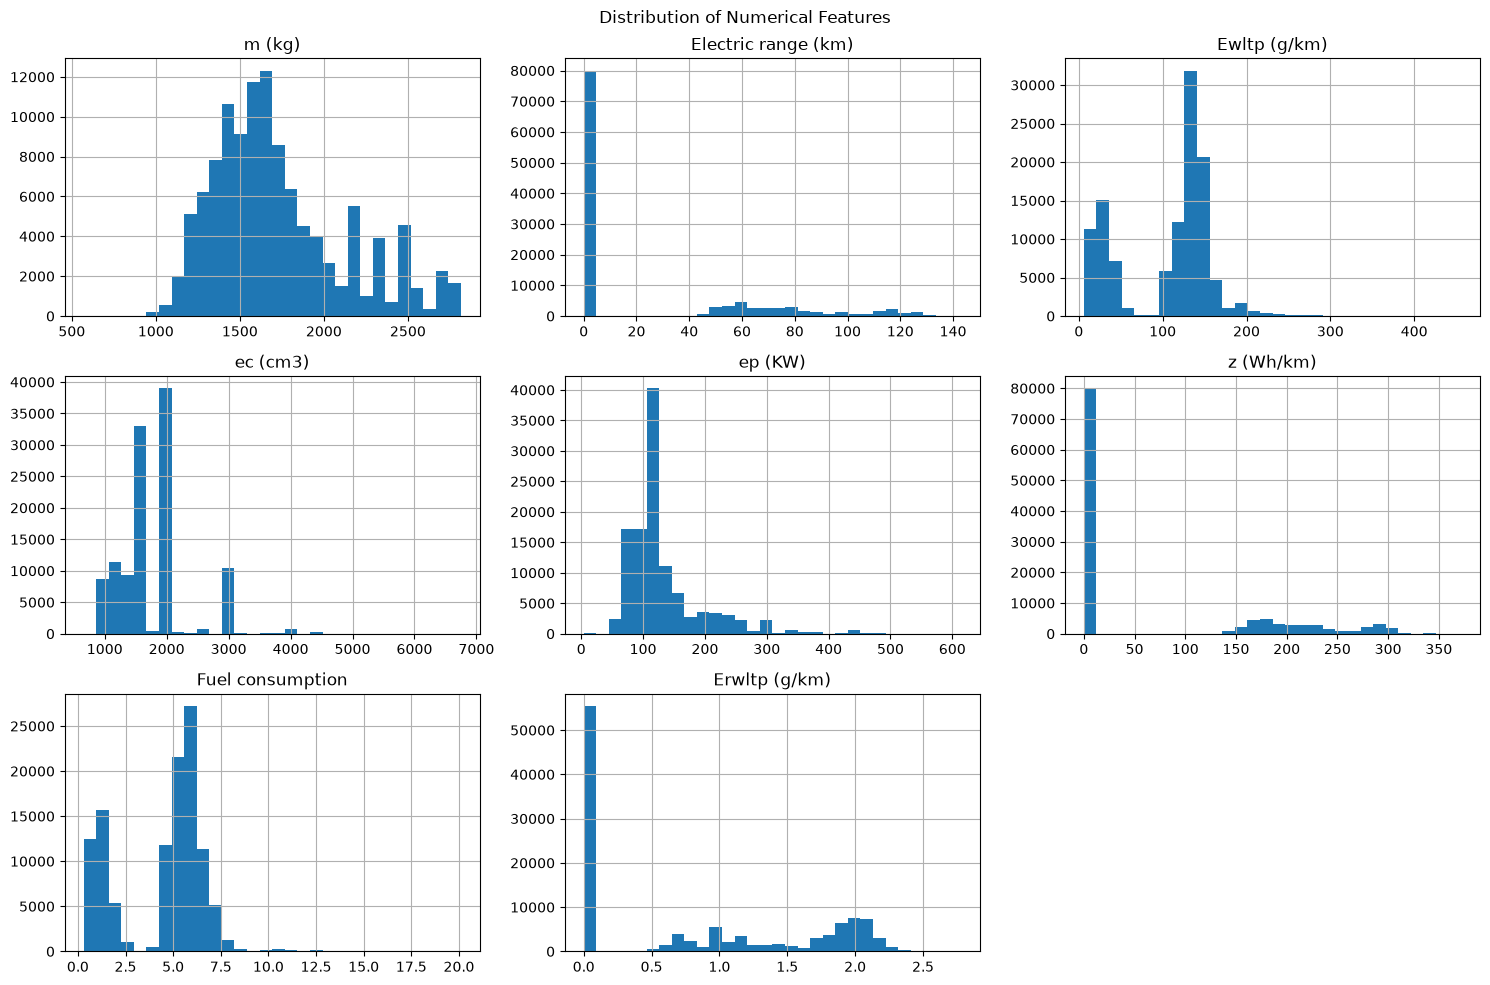

--- Feature Skewness ---
m (kg)                 0.847976
Electric range (km)    1.270781
Ewltp (g/km)          -0.345080
ec (cm3)               1.450601
ep (KW)                2.237823
z (Wh/km)              1.078145
Fuel consumption      -0.310122
Erwltp (g/km)          0.406389
dtype: float64


In [27]:
dist_graphs()

In [28]:
def summary():
    
    num_cols = [
        "m (kg)", 
        "Electric range (km)", 
        "z (Wh/km)", 
        "Ewltp (g/km)", 
        "ec (cm3)", 
        "ep (KW)", 
        "Erwltp (g/km)",
        "Fuel consumption",
    ]
    
    preprocessing_summary = pd.DataFrame({
        "dtype": df_2024[num_cols].dtypes.astype(str),
        "missing_count": df_2024[num_cols].isna().sum(),
        "missing_pct": (df_2024[num_cols].isna().mean() * 100).round(2),
        "zero_count": (df_2024[num_cols] == 0).sum(),
        "zero_pct": ((df_2024[num_cols] == 0).mean() * 100).round(2),
        "unique_values": df_2024[num_cols].nunique(),
        "min": df_2024[num_cols].min(),
        "q1": df_2024[num_cols].quantile(0.25),
        "median": df_2024[num_cols].median(),
        "q3": df_2024[num_cols].quantile(0.75),
        "max": df_2024[num_cols].max()
    }).round(2)
    
    display(preprocessing_summary)

summary()

,dtype,missing_count,missing_pct,zero_count,zero_pct,unique_values,min,q1,median,q3,max
m (kg),float64,0,0.0,0,0.00,1069,570.0,1441.0,1645.00,1930.00,2815.00
Electric range (km),float64,0,0.0,80004,69.65,117,0.0,0.0,0.00,57.00,143.00
z (Wh/km),float64,0,0.0,80004,69.65,207,0.0,0.0,0.00,170.00,372.00
Ewltp (g/km),float64,0,0.0,0,0.00,319,6.0,38.0,128.00,141.00,456.00
ec (cm3),float64,0,0.0,0,0.00,90,658.0,1461.0,1598.00,1993.00,6749.00
ep (KW),float64,0,0.0,0,0.00,195,4.0,96.0,110.00,145.00,614.00
Erwltp (g/km),float64,0,0.0,55472,48.29,184,0.0,0.0,0.64,1.79,2.78
Fuel consumption,float64,0,0.0,0,0.00,154,0.3,1.7,5.30,5.90,20.10


In [29]:
print("Shape:", df_2024.shape)
print("\nDtypes:\n", df_2024.dtypes)
print("\nNaN counts:\n", df_2024.isna().sum())
print("\nTarget stats:\n", df_2024["Ewltp (g/km)"].describe())

Shape: (114871, 20)

Dtypes:
 Vehicle                    str
m (kg)                 float64
Ewltp (g/km)           float64
Ft                         str
Fm                         str
ec (cm3)               float64
ep (KW)                float64
z (Wh/km)              float64
Erwltp (g/km)          float64
Fuel consumption       float64
Electric range (km)    float64
IT_28                    int64
IT_29                    int64
IT_32                    int64
IT_33                    int64
IT_37                    int64
IT_none                  int64
Make_Encoded           float64
Model_Frequency          int64
Ft_petrol                int64
dtype: object

NaN counts:
 Vehicle                0
m (kg)                 0
Ewltp (g/km)           0
Ft                     0
Fm                     0
ec (cm3)               0
ep (KW)                0
z (Wh/km)              0
Erwltp (g/km)          0
Fuel consumption       0
Electric range (km)    0
IT_28                  0
IT_29                 

# Dropping 
- Erwltp
- Fuel consumption


In [30]:
df_2024.drop(
    columns=[
        "Erwltp (g/km)",
        "Fuel consumption",
        "Ft_petrol"
    ],
    errors="ignore",
    inplace=True
)

display(df_2024.head())
display(df_2024.info())


,Vehicle,m (kg),Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),Electric range (km),IT_28,IT_29,IT_32,IT_33,IT_37,IT_none,Make_Encoded,Model_Frequency
0,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS72VR21BAI0 - 1T - E1*2001/116*0211*63,1675.0,140.0,diesel,M,1968.0,110.0,0.0,0.0,0,1,0,0,0,0,122.325509,481
1,VOLKSWAGEN - TOURAN - DTRCAF - FM6FM6C90044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1632.0,134.0,diesel,M,1968.0,90.0,0.0,0.0,0,1,0,0,0,0,122.325509,481
2,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAI0 - 1T - E1*2001/116*0211*65,1631.0,137.0,diesel,M,1968.0,110.0,0.0,0.0,0,1,0,0,0,0,122.325509,481
3,VOLKSWAGEN - TOURAN - DTSBAC - FD7FD7GC0044BIS50VR21AAIM - 1T - E1*2001/116*0211*65,1631.0,137.0,diesel,M,1968.0,110.0,0.0,0.0,1,1,0,0,0,0,122.325509,481
4,VOLKSWAGEN - TOURAN - DTSBAF - FD7FD7GC0044BIS71VR21BAI0 - 1T - E1*2001/116*0211*65,1675.0,140.0,diesel,M,1968.0,110.0,0.0,0.0,0,1,0,0,0,0,122.325509,481


<class 'pandas.DataFrame'>
Index: 114871 entries, 0 to 119379
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Vehicle              114871 non-null  str    
 1   m (kg)               114871 non-null  float64
 2   Ewltp (g/km)         114871 non-null  float64
 3   Ft                   114871 non-null  str    
 4   Fm                   114871 non-null  str    
 5   ec (cm3)             114871 non-null  float64
 6   ep (KW)              114871 non-null  float64
 7   z (Wh/km)            114871 non-null  float64
 8   Electric range (km)  114871 non-null  float64
 9   IT_28                114871 non-null  int64  
 10  IT_29                114871 non-null  int64  
 11  IT_32                114871 non-null  int64  
 12  IT_33                114871 non-null  int64  
 13  IT_37                114871 non-null  int64  
 14  IT_none              114871 non-null  int64  
 15  Make_Encoded         114871 non-n

None

## Now we need to split train and test so that we encode the categorical columns amd implement standardization/normalization on the numerical ones.

### Let's export our dataframe:

In [31]:
df_2024.to_csv("../data/processed/EU/2024_FR_cleaned_final.csv", index = False)


In [32]:
# Split train - test
y = df_2024["Ewltp (g/km)"]
X = df_2024.drop(["Ewltp (g/km)", "Vehicle"], axis=1)  # We won't include Vehicle in the model

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# We need to encode Ft, Fm columns
# We choose one hot encoder for Ft & Fm

# ColumnTransformer for One-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["Ft", "Fm"]),
    ],
    remainder="passthrough",  # The other columns (ec, ep, Mt, Fuel consumption, etc.) remain unchanged
)

# Apply the transformation to the train and test sets
X_train_encoded = preprocessor.fit_transform(X_train, y_train)
X_test_encoded = preprocessor.transform(X_test)

# ColumnTransformer returns a NumPy array, we want to keep our format as Dataframes
ohe = preprocessor.named_transformers_["ohe"]
ohe_cols = ohe.get_feature_names_out(["Ft", "Fm"]).tolist()

# Remainder columns (passthrough): All columns except Ft, and Fm
remainder_cols = [col for col in X.columns if col not in ["Ft", "Fm"]]

# All column names
all_columns = ohe_cols + remainder_cols

# Convert to a DataFrame
X_train_encoded = pd.DataFrame(X_train_encoded, columns=all_columns, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=all_columns, index=X_test.index)

# Control
print(X_train_encoded.shape)
print(X_test_encoded.shape)
print(X_train_encoded.columns.tolist())

(91896, 19)
(22975, 19)
['Ft_diesel', 'Ft_petrol', 'Ft_petrol/electric', 'Fm_H', 'Fm_M', 'Fm_P', 'm (kg)', 'ec (cm3)', 'ep (KW)', 'z (Wh/km)', 'Electric range (km)', 'IT_28', 'IT_29', 'IT_32', 'IT_33', 'IT_37', 'IT_none', 'Make_Encoded', 'Model_Frequency']


### Now let's scale our data

In [33]:
# Prepare Scaled Data (FOR LINEAR MODELS ONLY) ---
# Scale only the continuous numeric columns
numeric_cols = [
    "ec (cm3)", "ep (KW)", "m (kg)", "z (Wh/km)", 
    "Electric range (km)"
]

scaler = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_cols),
    ],
    remainder="passthrough",
)

X_train_encoded_scaled = scaler.fit_transform(X_train_encoded)
X_test_encoded_scaled = scaler.transform(X_test_encoded)


# Preserve column names (scaled columns first, remainder last)
scaled_cols = numeric_cols
remainder_cols = [col for col in X_train_encoded.columns if col not in numeric_cols]
all_columns = scaled_cols + remainder_cols

# Convert to a DataFrame
X_train_encoded_scaled = pd.DataFrame(
    X_train_encoded_scaled,
    columns=all_columns,
    index=X_train_encoded.index
)

X_test_encoded_scaled = pd.DataFrame(
    X_test_encoded_scaled,
    columns=all_columns,
    index=X_test_encoded.index
)

# Control
print("X_train_encoded_scaled shape:", X_train_encoded_scaled.shape)
print("X_train_encoded_scaled columns list:", X_train_encoded_scaled.columns.tolist())
print("X_train_encoded_scaled empty data:", X_train_encoded_scaled.isna().sum().sum())
print("X_train_encoded_scaled data types:", X_train_encoded_scaled.dtypes.value_counts())
#Print verification of scaled data (mean ≈ 0, std ≈ 1)
print("X_train_encoded_scaled scaled columns mean:\n", X_train_encoded_scaled[numeric_cols].mean().round(4))
print("\nX_train_encoded_scaled scaled columns std:\n", X_train_encoded_scaled[numeric_cols].std().round(4))
print("\n*********\n")
print("X_test_encoded_scaled shape:", X_test_encoded_scaled.shape)
print("X_test_encoded_scaled columns list:", X_test_encoded_scaled.columns.tolist())
print("X_test_encoded_scaled empty data:", X_test_encoded_scaled.isna().sum().sum())
print("X_test_encoded_scaled data types:", X_test_encoded_scaled.dtypes.value_counts())

X_train_encoded_scaled shape: (91896, 19)
X_train_encoded_scaled columns list: ['ec (cm3)', 'ep (KW)', 'm (kg)', 'z (Wh/km)', 'Electric range (km)', 'Ft_diesel', 'Ft_petrol', 'Ft_petrol/electric', 'Fm_H', 'Fm_M', 'Fm_P', 'IT_28', 'IT_29', 'IT_32', 'IT_33', 'IT_37', 'IT_none', 'Make_Encoded', 'Model_Frequency']
X_train_encoded_scaled empty data: 0
X_train_encoded_scaled data types: float64    19
Name: count, dtype: int64
X_train_encoded_scaled scaled columns mean:
 ec (cm3)               0.0
ep (KW)               -0.0
m (kg)                -0.0
z (Wh/km)              0.0
Electric range (km)    0.0
dtype: float64

X_train_encoded_scaled scaled columns std:
 ec (cm3)               1.0
ep (KW)                1.0
m (kg)                 1.0
z (Wh/km)              1.0
Electric range (km)    1.0
dtype: float64

*********

X_test_encoded_scaled shape: (22975, 19)
X_test_encoded_scaled columns list: ['ec (cm3)', 'ep (KW)', 'm (kg)', 'z (Wh/km)', 'Electric range (km)', 'Ft_diesel', 'Ft_petrol', '

# Let's save our split data and artefacts:

In [34]:
artefacts_dir = Path("../artefacts")
split_dir = Path("../data/processed/eu/splits")




# If the folder doesn't exist, create it; if it does exist, don't return an error
artefacts_dir.mkdir(parents=True, exist_ok=True)
split_dir.mkdir(parents=True, exist_ok=True)

# save raw split data (not encoded, not scaled, only split)
X_train_raw = df_2024.loc[X_train.index].copy()
X_test_raw = df_2024.loc[X_test.index].copy()

X_train_raw.to_parquet(split_dir / "X_train_raw.parquet", index=True)
X_test_raw.to_parquet(split_dir / "X_test_raw.parquet", index=True)

# save encoded split data
X_train_encoded.to_parquet(split_dir / "X_train_encoded.parquet", index=True)
X_test_encoded.to_parquet(split_dir / "X_test_encoded.parquet", index=True)

# save encoded and scaled split data
X_train_encoded_scaled.to_parquet(split_dir / "X_train_encoded_scaled.parquet", index=True)
X_test_encoded_scaled.to_parquet(split_dir / "X_test_encoded_scaled.parquet", index=True)

y_train.to_frame(name="Ewltp (g/km)").to_parquet(split_dir / "y_train.parquet", index=True)
y_test.to_frame(name="Ewltp (g/km)").to_parquet(split_dir / "y_test.parquet", index=True)

# save the encoder and the scaler
joblib.dump(preprocessor, artefacts_dir / "ohe_encoder.joblib")
joblib.dump(scaler, artefacts_dir / "numeric_scaler.joblib")

# control
print("X_train_raw saved:", (split_dir / "X_train_raw.parquet").exists())
print("X_test_raw saved:", (split_dir / "X_test_raw.parquet").exists())
print("******")
print("X_train_encoded saved:", (split_dir / "X_train_encoded.parquet").exists())
print("X_test_encoded saved:", (split_dir / "X_test_encoded.parquet").exists())
print("******")
print("X_train_encoded_scaled saved:", (split_dir / "X_train_encoded_scaled.parquet").exists())
print("X_test_encoded_scaled saved:", (split_dir / "X_test_encoded_scaled.parquet").exists())
print("******")
print("y_train saved:", (split_dir / "y_train.parquet").exists())
print("y_test saved:", (split_dir / "y_test.parquet").exists())

print("******")
print("Preprocessor saved:", (artefacts_dir / "ohe_encoder.joblib").exists())
print("Scaler saved:", (artefacts_dir / "numeric_scaler.joblib").exists())

X_train_raw saved: True
X_test_raw saved: True
******
X_train_encoded saved: True
X_test_encoded saved: True
******
X_train_encoded_scaled saved: True
X_test_encoded_scaled saved: True
******
y_train saved: True
y_test saved: True
******
Preprocessor saved: True
Scaler saved: True


# Summary: Vehicle CO2 Emissions Data Preparation

## 1. Package Setup and Data Loading

The required Python data-science and machine-learning libraries were imported, including `pandas`, `numpy`, `matplotlib`, `seaborn`, scikit-learn tools, `joblib`, and `category_encoders`.

The cleaned 2024 France vehicle dataset was loaded from `2024_FR_cleaned.csv`.

The dataset initially contained **119,380 rows and 18 columns**. The non-predictive `r` column was removed because it did not provide useful information for predicting CO₂ emissions.

---

## 2. Vehicle Feature Engineering

The original combined `Vehicle` text field was parsed into separate `Make` and `Model` features.

To reduce the high number of unique vehicle manufacturers, only the **30 most frequent makes** were retained as individual categories. All remaining manufacturers were grouped into an `OTHER` category.

This preserved approximately **99.61% of total market coverage** while reducing category cardinality.

---

## 3. Feature Encoding

### Target Encoding — `Make_Encoded`

The grouped vehicle manufacturer feature, `Make_Grouped`, was transformed into the mean CO₂ emissions value for each manufacturer.

This preserved useful information about the relationship between vehicle manufacturer and emissions without creating a large number of one-hot-encoded columns.

### Frequency Encoding — `Model_Frequency`

Vehicle models were transformed into their occurrence frequencies in the dataset.

This represented model popularity while avoiding the very high-dimensional feature space that would result from one-hot encoding thousands of individual models.

### One-Hot Encoding — `Ft_` and `Fm_` Features

Fuel type (`Ft`) and fuel mode (`Fm`) were converted into binary indicator columns.

One-hot encoding prevents models from incorrectly treating fuel categories as if they have an ordinal relationship.

After creating the encoded features, the original raw categorical columns were removed:

- `Make`
- `Model`
- `Make_Grouped`

---

## 4. Fuel Category Filtering

The distributions of fuel type (`Ft`) and fuel mode (`Fm`) were inspected before filtering.

The dataset retained the primary fuel categories:

- Petrol
- Petrol/electric
- Diesel

Low-frequency fuel categories were removed:

- `diesel/electric`
- `e85`
- `lpg`

These categories represented only a small proportion of the data and could introduce unstable or unreliable patterns during model training.

---

## 5. Target Leakage Prevention

Fuel consumption and `Erwltp` were removed from the feature matrix to prevent target leakage.

Fuel consumption has a direct physical and stoichiometric relationship with CO₂ emissions. Including it could allow the model to predict emissions using an overly direct proxy instead of learning meaningful relationships from vehicle characteristics, such as:

- Vehicle mass
- Engine displacement
- Engine power
- Fuel type
- Vehicle manufacturer

`Erwltp` was also removed because it represents post-test regulatory adjustments and may contain information too closely related to the target variable.

---

## 6. Train/Test Split

The data was divided into training and test sets using an **80/20 split**:

```python
train_test_split(..., random_state=42)
```

The split was performed before scaling and outlier filtering.

This helps prevent data leakage by ensuring that the test set remains a clean, unseen benchmark for final model evaluation.

---

## 7. Outlier and Data-Quality Handling

Summary statistics and numerical distributions were examined to understand feature ranges, skewness, and possible anomalies.

Histograms were used to visualize the distributions of numerical variables.

Rows where `Electric range (km)` was suspiciously high and justified to be currupt data have been removed.

---

## 8. Feature Standardization

Continuous numerical features were standardized using `StandardScaler`.

The scaler was fitted only on the training data to prevent information from the test set leaking into the training process:

```python
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

Standardization places numerical variables on a comparable scale, typically with:

- Mean close to `0`
- Standard deviation close to `1`

This is particularly important for models that are sensitive to feature scale, including linear models, support vector machines, k-nearest neighbors, and neural networks.